In [169]:
import seaborn as sns
import math
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score
from xgboost import XGBClassifier, DMatrix,plot_importance
import shap

#  1. Preprocess and Prepare Data.

## Functions

In [170]:
def plot_distribution(df, columns,kde=False):

    fig, axes = plt.subplots(len(columns), 2, figsize=(14, len(columns) * 3), constrained_layout=True)
    axes = axes.flatten()  # Flatten the axes for easy indexing

    # Loop over the categorical columns and plot each one
    for i, col in enumerate(columns):
        sns.histplot(df[col], kde=kde, ax=axes[i], color='red')
        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Occurrences")
        axes[i].grid(True)

    # Hide any remaining empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Show the plot
    plt.show()

In [171]:

def plot_boxplots(df, columns, plots_per_row=2):
    n_cols = plots_per_row
    n_rows = math.ceil(len(columns) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), constrained_layout=True)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.boxplot(x=df[col], ax=axes[i], color='red')
        axes[i].set_title(f"Boxplot of {col}")
        axes[i].set_xlabel("Value")
        axes[i].grid(True)

    # Nasconde eventuali subplot vuoti
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.show()

## 1.1) Exploration Datasets

In [172]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
df

Dataset shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,...,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,...,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,Male,1958-10-01,57,Greater than 45,Other,...,1,Low,2014-01-14,2014-01-13,2014-01-14,0,0,808,0,0
7212,11000,farrah jean,farrah,jean,2014-03-09,Female,1982-11-17,33,25 - 45,African-American,...,2,Low,2014-03-09,2014-03-08,2014-03-09,3,0,754,0,0


In [173]:
df.describe()

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,6907.000000,7192.000000,7214.000000,2316.000000,0.0,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000
mean,5501.255753,34.817993,0.067230,4.509565,0.090934,0.109371,3.472415,3.304763,57.731368,0.481148,20.269430,NaN,0.113529,4.509565,3.691849,3.472415,11.465068,553.436651,0.382867,0.450652
std,3175.706870,11.888922,0.473972,2.856396,0.485239,0.501586,4.882538,75.809505,329.740215,0.499679,74.871668,NaN,0.317261,2.856396,2.510148,4.882538,46.954563,399.020583,0.486120,0.497593
min,1.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-414.000000,0.000000,0.000000,-1.000000,NaN,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2735.250000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,1.000000,0.000000,0.000000,148.250000,0.000000,0.000000
50%,5509.500000,31.000000,0.000000,4.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,4.000000,3.000000,2.000000,0.000000,530.500000,0.000000,0.000000
75%,8246.500000,42.000000,0.000000,7.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,7.000000,5.000000,5.000000,1.000000,914.000000,1.000000,1.000000
max,11001.000000,96.000000,20.000000,10.000000,13.000000,17.000000,38.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,38.000000,937.000000,1186.000000,1.000000,1.000000


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   object 
 2   first                    7214 non-null   object 
 3   last                     7214 non-null   object 
 4   compas_screening_date    7214 non-null   object 
 5   sex                      7214 non-null   object 
 6   dob                      7214 non-null   object 
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   object 
 9   race                     7214 non-null   object 
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count            

## 1.2 Dataset reduction

In [175]:
df_cleaned = df[
    (df['days_b_screening_arrest'] >= -30) &
    (df['days_b_screening_arrest'] <= 30) &
    (df['is_recid'] != -1) &
    (df['c_charge_degree'] != 'O')
]
df['c_jail_in'] = pd.to_datetime(df['c_jail_in'])
df['c_jail_out'] = pd.to_datetime(df['c_jail_out'])

In [176]:
columns_to_drop_custom = [
    'name',
    'first',
    'last',
    'dob',
    'compas_screening_date',
    'screening_date',
    'v_screening_date',
    'c_jail_in',
    'c_jail_out',
    'r_jail_in',
    'r_jail_out',
    'vr_offense_date',
    'c_offense_date',
    'c_arrest_date',
    'r_offense_date',
    'vr_case_number',
    'vr_charge_desc',
    'c_case_number',
    'r_case_number',
    'in_custody',
    'out_custody',
    'c_charge_desc',
    'r_charge_desc',
    'id'
]

df_cleaned = df_cleaned.drop(columns=columns_to_drop_custom, errors='ignore')
df_cleaned['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days

print(f"Dimension after drop: {df_cleaned.shape}")
df_cleaned

Dimension after drop: (6172, 30)


,sex,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,...,score_text,v_type_of_assessment,v_decile_score,v_score_text,priors_count.1,start,end,event,two_year_recid,length_of_stay
0,Male,69,Greater than 45,Other,0,1,0,0,0,-1.0,...,Low,Risk of Violence,1,Low,0,0,327,0,0,0.0
1,Male,34,25 - 45,African-American,0,3,0,0,0,-1.0,...,Low,Risk of Violence,1,Low,0,9,159,1,1,10.0
2,Male,24,Less than 25,African-American,0,4,0,1,4,-1.0,...,Low,Risk of Violence,3,Low,4,0,63,0,1,1.0
5,Male,44,25 - 45,Other,0,1,0,0,0,0.0,...,Low,Risk of Violence,1,Low,0,1,853,0,0,1.0
6,Male,41,25 - 45,Caucasian,0,6,0,0,14,-1.0,...,Medium,Risk of Violence,2,Low,14,5,40,1,1,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,Male,23,Less than 25,African-American,0,7,0,0,0,-1.0,...,Medium,Risk of Violence,5,Medium,0,1,860,0,0,1.0
7210,Male,23,Less than 25,African-American,0,3,0,0,0,-1.0,...,Low,Risk of Violence,5,Medium,0,1,790,0,0,1.0
7211,Male,57,Greater than 45,Other,0,1,0,0,0,-1.0,...,Low,Risk of Violence,1,Low,0,0,808,0,0,1.0
7212,Female,33,25 - 45,African-American,0,2,0,0,3,-1.0,...,Low,Risk of Violence,2,Low,3,0,754,0,0,1.0


In [177]:
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns

## 1.2)  Cathegorical Feautures


In [178]:
for col in categorical_columns:
    print(f"\n{col}:{df_cleaned[col].unique()}")


sex:['Male' 'Female']

age_cat:['Greater than 45' '25 - 45' 'Less than 25']

race:['Other' 'African-American' 'Caucasian' 'Hispanic' 'Asian'
 'Native American']

c_charge_degree:['F' 'M']

r_charge_degree:[nan '(F3)' '(M1)' '(F2)' '(M2)' '(MO3)' '(F1)' '(F6)' '(F7)' '(CO3)'
 '(F5)']

vr_charge_degree:[nan '(F3)' '(F1)' '(M1)' '(F2)' '(MO3)' '(M2)' '(F6)' '(F7)' '(F5)']

type_of_assessment:['Risk of Recidivism']

score_text:['Low' 'Medium' 'High']

v_type_of_assessment:['Risk of Violence']

v_score_text:['Low' 'High' 'Medium']


In [179]:
df_cleaned = df_cleaned.drop(columns=['type_of_assessment','v_type_of_assessment'], errors='ignore')


## 1.3) Find duplicated value on the dataset

In [180]:
# Identify duplicated rows
bool_series = df_cleaned.duplicated(keep='first')

# Count the number of duplicated rows
num_duplicates = bool_series.sum()

# Filter out duplicated rows
train_df = df_cleaned[~bool_series]

# Print the results
print(f"Number of duplicated rows removed: {num_duplicates}")
print(f"Shape of the DataFrame after removing duplicates: {train_df.shape}")

Number of duplicated rows removed: 1
Shape of the DataFrame after removing duplicates: (6171, 28)


## 1.4) Find missing values on the dataset

In [181]:
missing_counts = df_cleaned.isnull().sum()

missing_counts = missing_counts[missing_counts > 0]

for column, count in missing_counts.items():
    print(f"'{column}': {count} missing values")

'r_charge_degree': 3182 missing values
'r_days_from_arrest': 4175 missing values
'violent_recid': 6172 missing values
'vr_charge_degree': 5480 missing values


In [182]:
df_cleaned = df_cleaned.drop(columns=['vr_charge_degree','violent_recid','r_days_from_arrest','r_charge_degree'], errors='ignore')

In [183]:
df_cleaned['days_b_screening_arrest'] = df_cleaned['days_b_screening_arrest'].fillna(df_cleaned['days_b_screening_arrest'].median()).astype(int)
df_cleaned['c_days_from_compas'] = df_cleaned['c_days_from_compas'].fillna(df_cleaned['c_days_from_compas'].median()).astype(int)

## 1.5) Find outliers.

In [184]:
numerical_columns = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
binary_columns = ['is_recid', 'is_violent_recid', 'event', 'two_year_recid']
numerical_columns

['age',
 'juv_fel_count',
 'decile_score',
 'juv_misd_count',
 'juv_other_count',
 'priors_count',
 'is_recid',
 'is_violent_recid',
 'decile_score.1',
 'v_decile_score',
 'priors_count.1',
 'start',
 'end',
 'event',
 'two_year_recid',
 'length_of_stay']

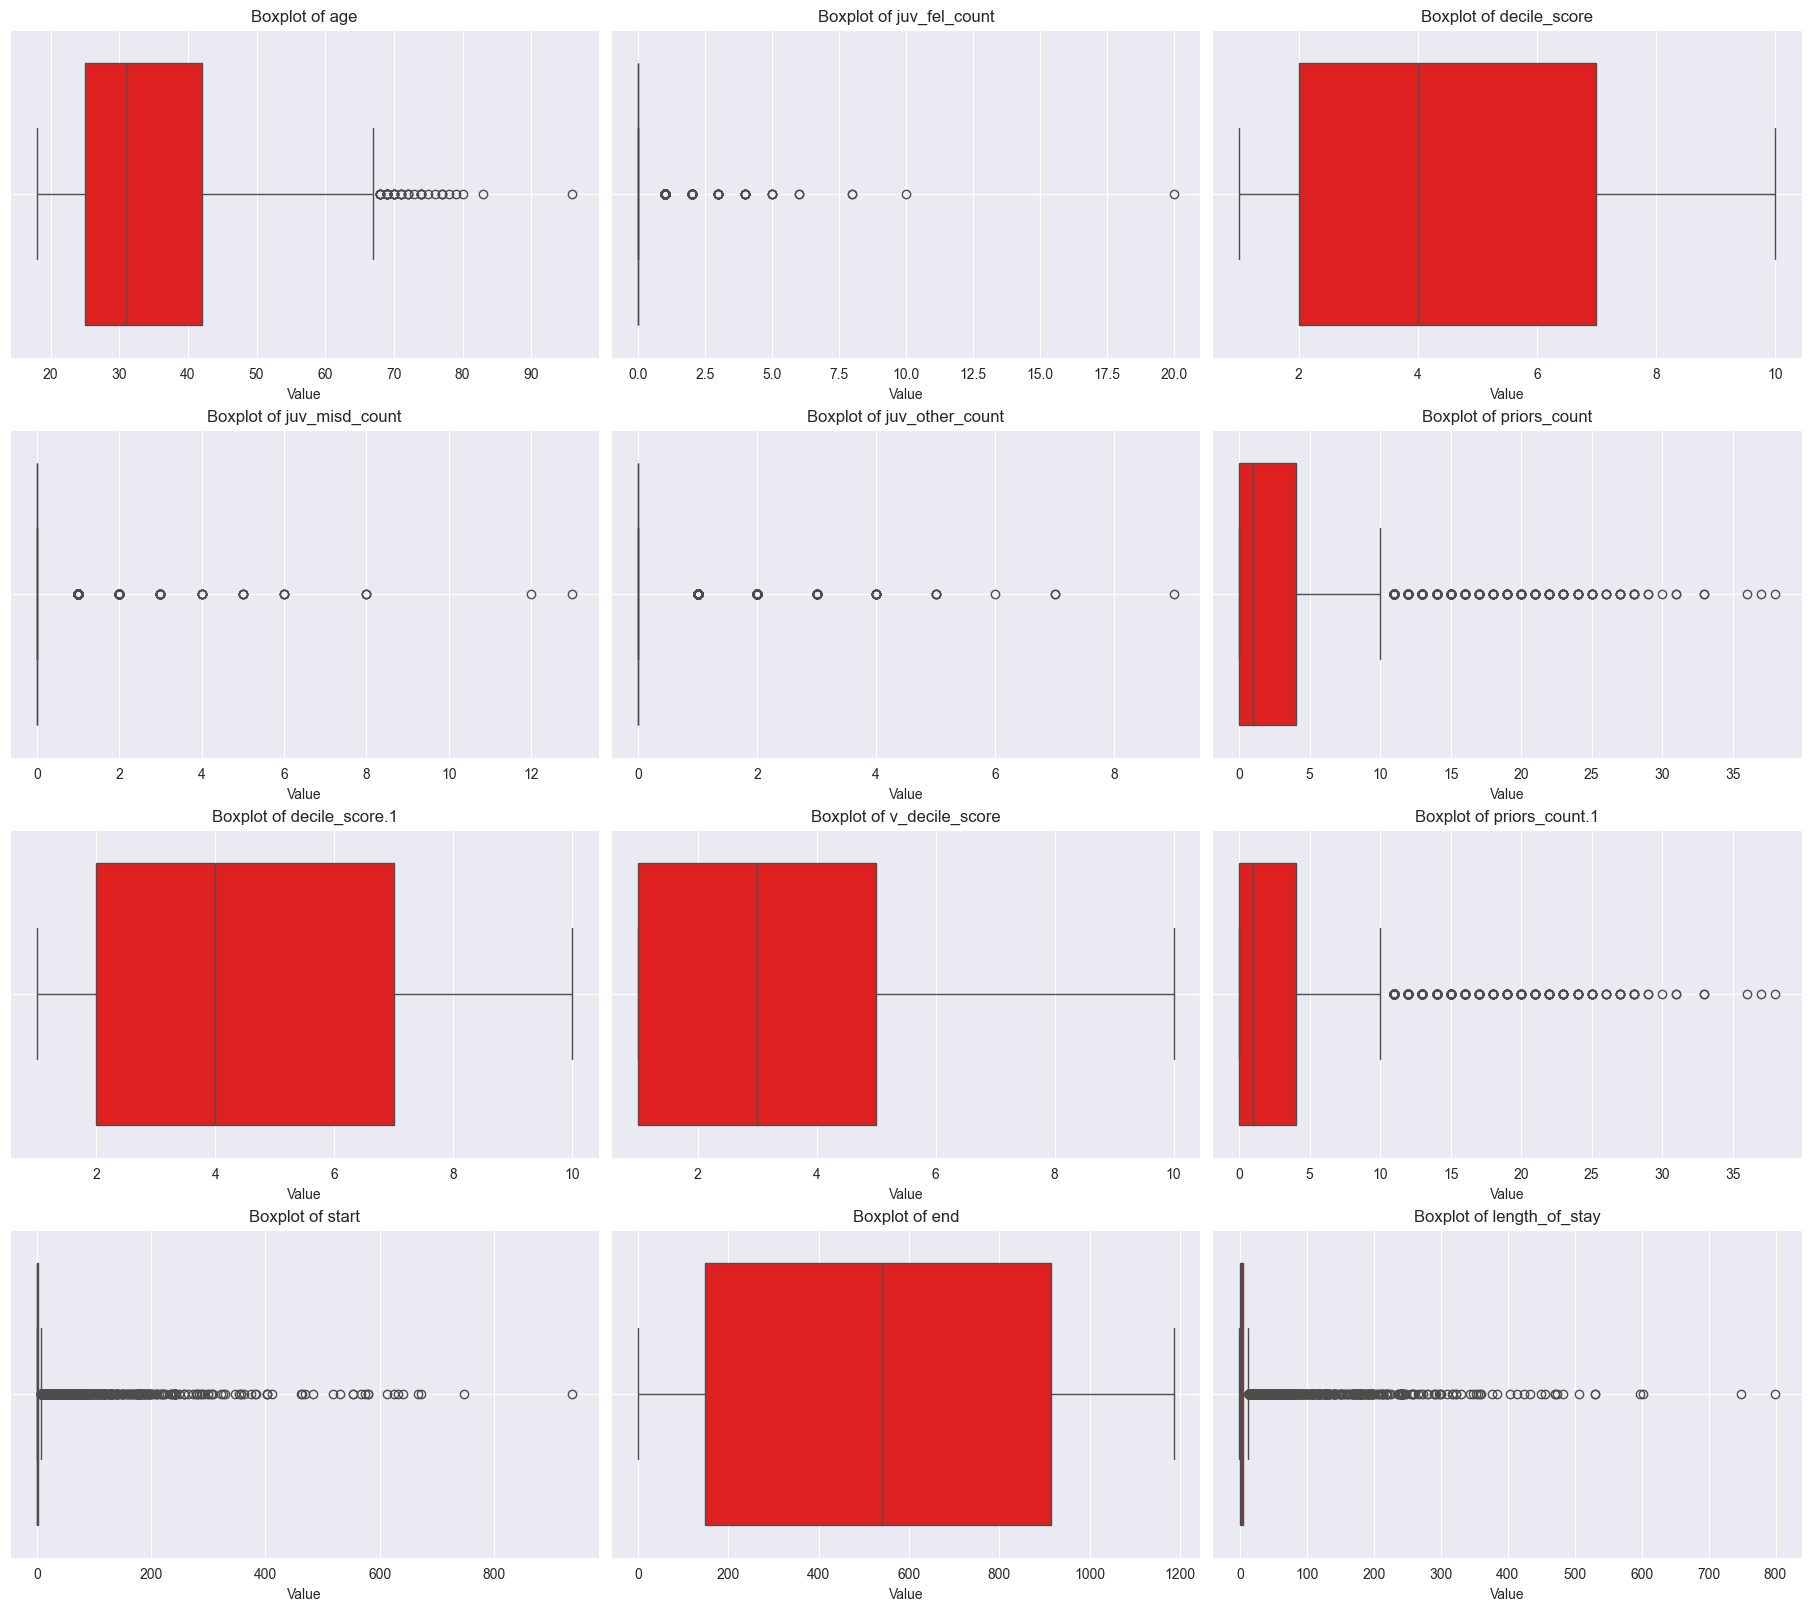

In [185]:
plot_boxplots(df_cleaned, [col for col in numerical_columns if col not in binary_columns], plots_per_row=3)

## 1.6) Visualize the pair plot to understand the pairwise relationship.

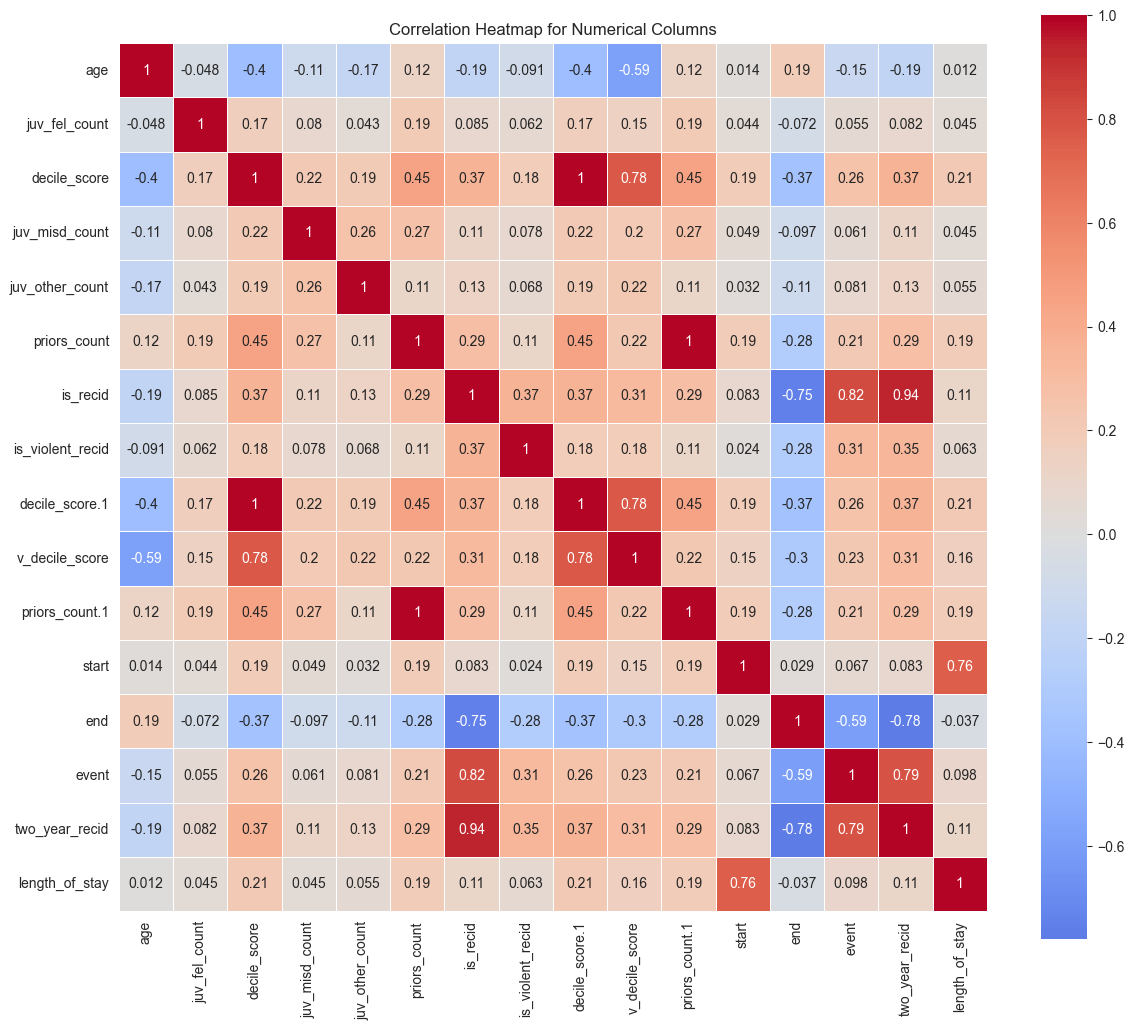

In [186]:
correlation_matrix = df_cleaned[numerical_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title("Correlation Heatmap for Numerical Columns")

plt.show()

## 1.7) Explore distribution

### 1.7.1) Numerical

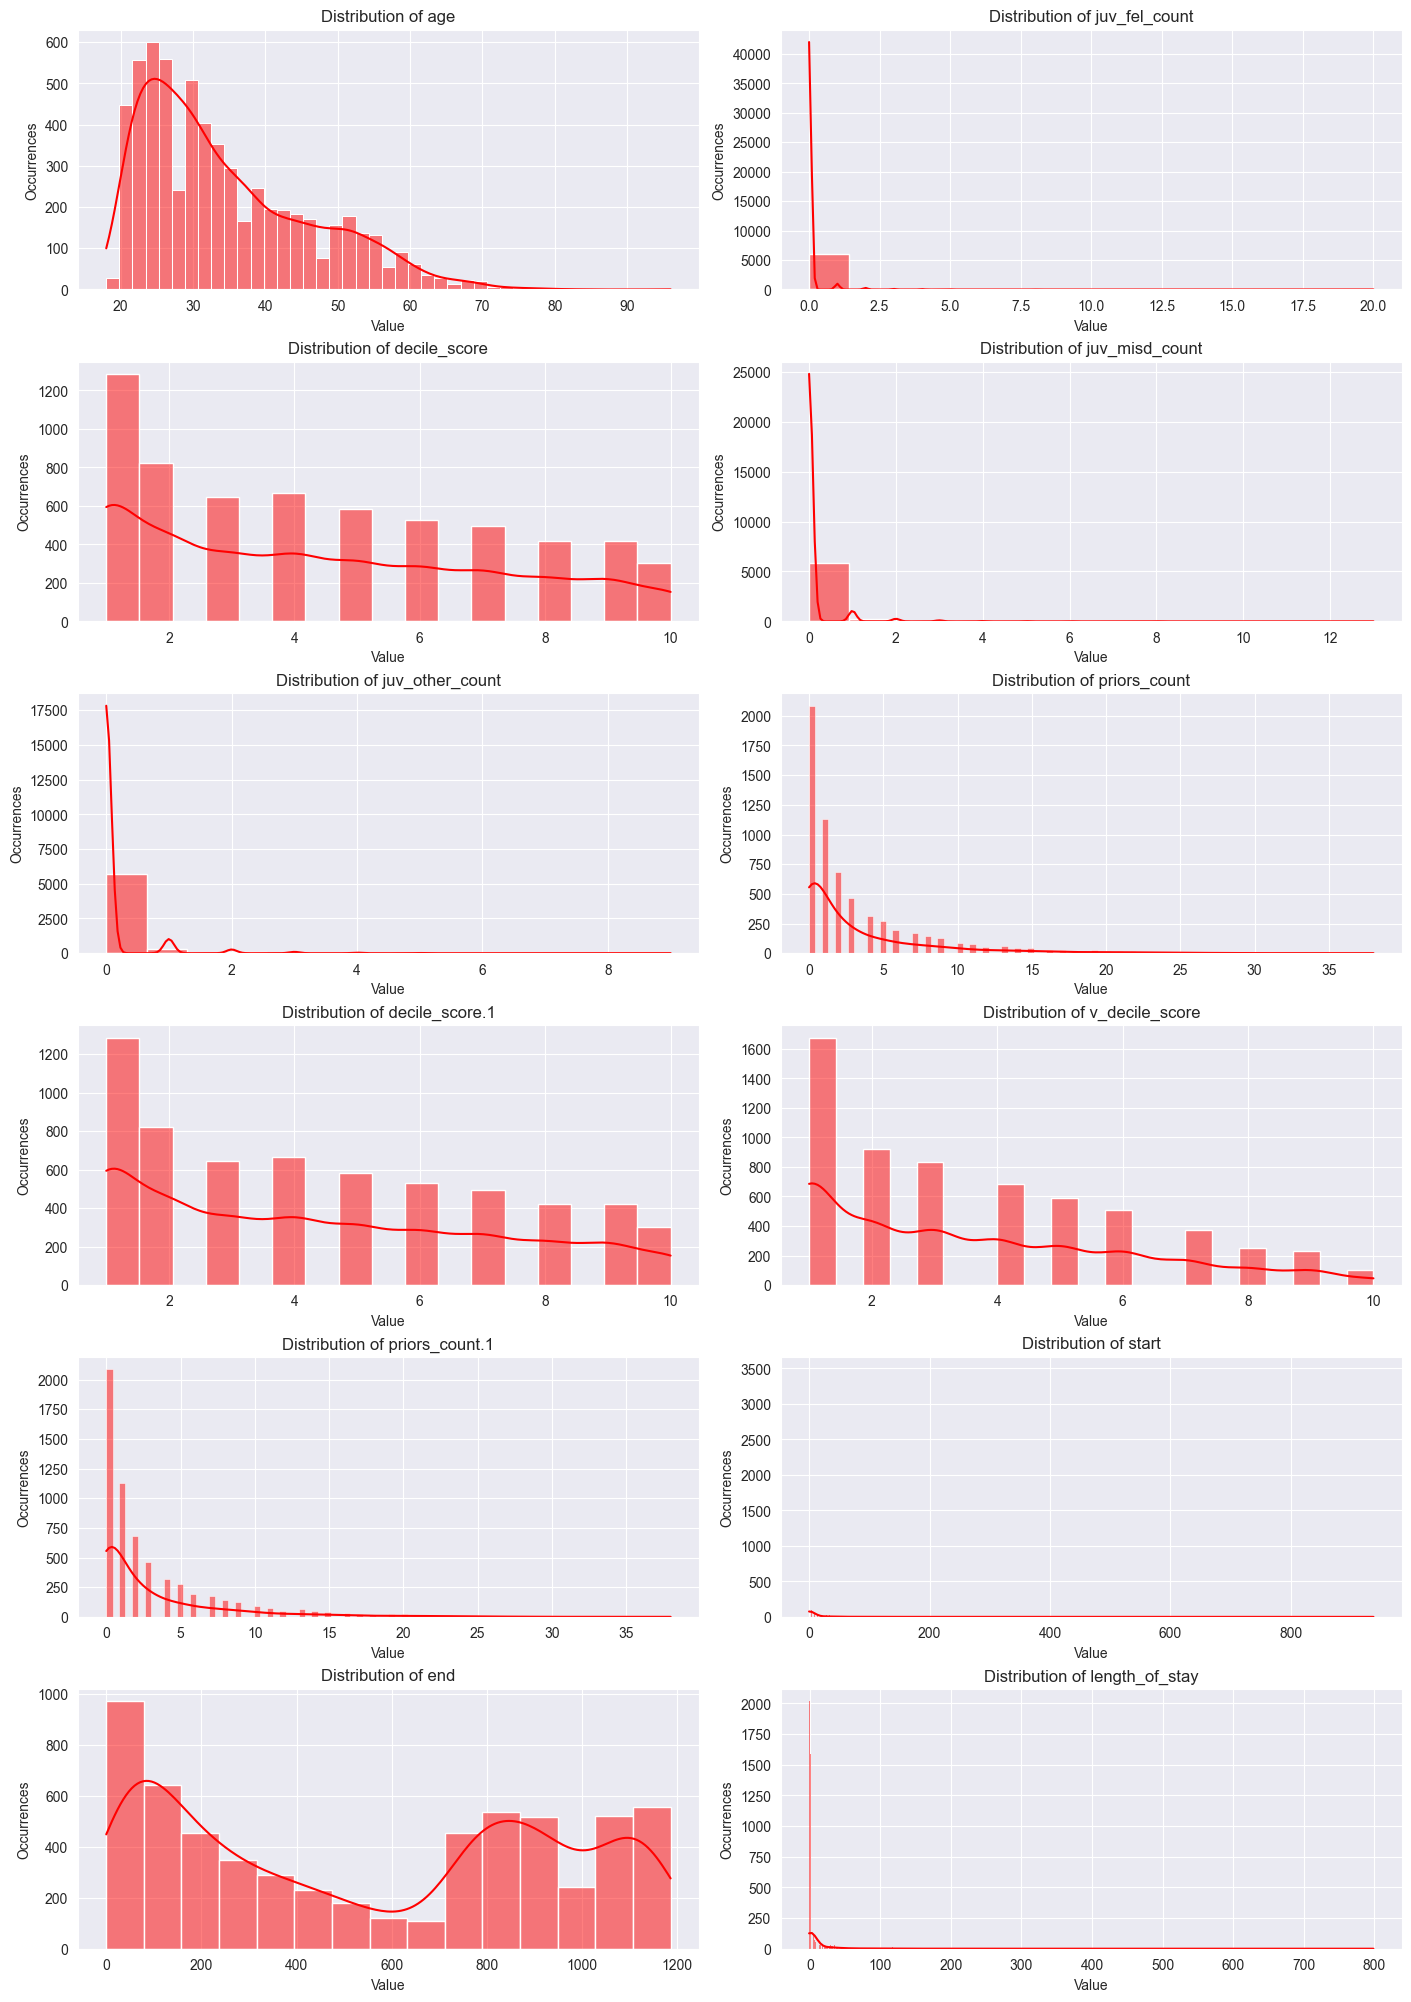

In [187]:
plot_distribution(df_cleaned, [col for col in numerical_columns if col not in binary_columns],kde=True)

### 1.7.2) Cathegorical


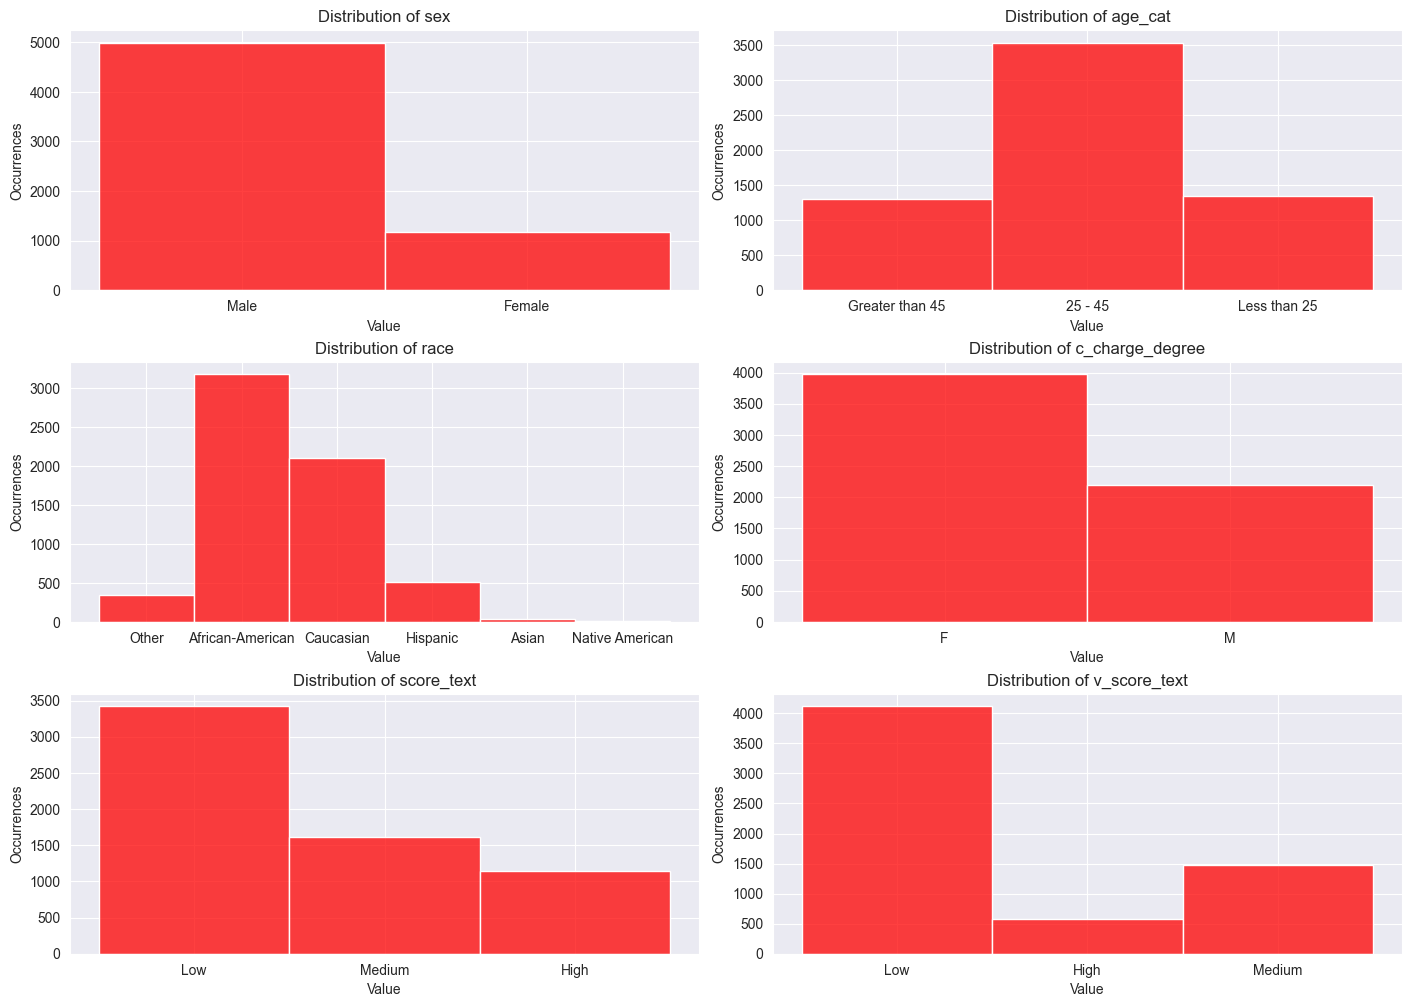

In [188]:
categorical_columns = df_cleaned.select_dtypes(include='object').columns.tolist()
plot_distribution(df_cleaned, categorical_columns)

## 1.8 Data Encoding

### 1.8.1) One-hot-Encoding

In [189]:
# List of categorical columns to encode
columns_to_encode = ['race']

df_encoded = pd.get_dummies(df_cleaned, columns=['race'], prefix='race')
race_dummies = [col for col in df_encoded.columns if col.startswith('race_')]
df_encoded[race_dummies] = df_encoded[race_dummies].astype(int)

### 1.8.2) Ordinal Encoding

In [190]:
age_cat_map = {
    'Less than 25': 0,
    '25 - 45': 1,
    'Greater than 45': 2
}

score_text_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

v_score_text_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

In [191]:
df_encoded['age_cat'] = df_encoded['age_cat'].map(age_cat_map)
df_encoded['score_text'] = df_encoded['score_text'].map(score_text_map)
df_encoded['v_score_text'] = df_encoded['v_score_text'].map(v_score_text_map)

### 1.8.3) Binary Encoding

In [192]:
binary_maps = {
    'sex': {'Female': 0, 'Male': 1},
    'c_charge_degree': {'M': 1, 'F': 0}
}

df_encoded['sex'] = df_encoded['sex'].map(binary_maps['sex'])
df_encoded['c_charge_degree'] = df_encoded['c_charge_degree'].map(binary_maps['c_charge_degree'])

In [193]:
df_encoded

,sex,age,age_cat,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,...,end,event,two_year_recid,length_of_stay,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other
0,1,69,2,0,1,0,0,0,-1,1,...,327,0,0,0.0,0,0,0,0,0,1
1,1,34,1,0,3,0,0,0,-1,1,...,159,1,1,10.0,1,0,0,0,0,0
2,1,24,0,0,4,0,1,4,-1,1,...,63,0,1,1.0,1,0,0,0,0,0
5,1,44,1,0,1,0,0,0,0,0,...,853,0,0,1.0,0,0,0,0,0,1
6,1,41,1,0,6,0,0,14,-1,1,...,40,1,1,6.0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,1,23,0,0,7,0,0,0,-1,1,...,860,0,0,1.0,1,0,0,0,0,0
7210,1,23,0,0,3,0,0,0,-1,1,...,790,0,0,1.0,1,0,0,0,0,0
7211,1,57,2,0,1,0,0,0,-1,1,...,808,0,0,1.0,0,0,0,0,0,1
7212,0,33,1,0,2,0,0,3,-1,1,...,754,0,0,1.0,1,0,0,0,0,0


# 2. Analyze Data

## 2.1 Distribution of protected columns

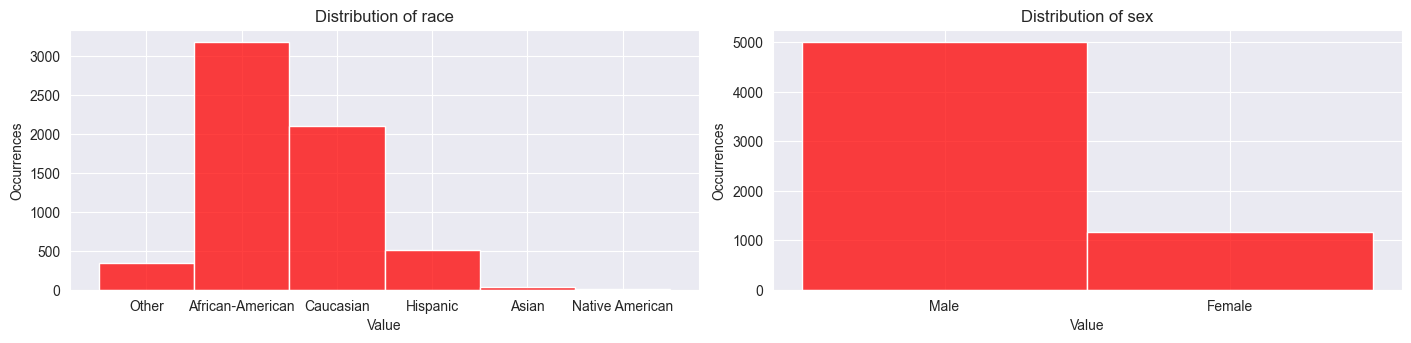

In [194]:
plot_distribution(df_cleaned, ["race","sex"])


## 2.2 Score Text vs. Violent Recidivism

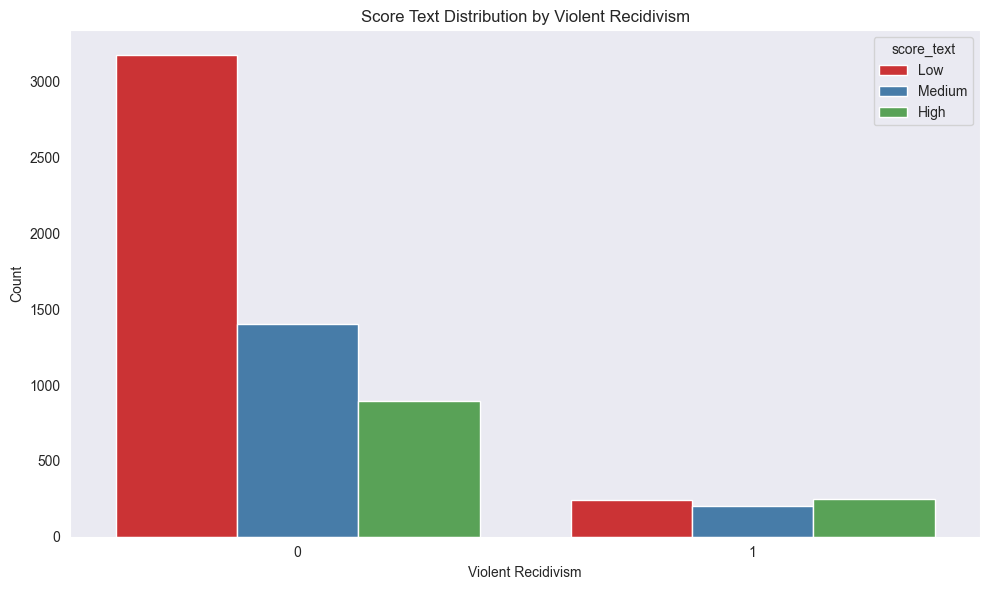

In [195]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, x='is_violent_recid', hue='score_text', palette='Set1')

plt.title("Score Text Distribution by Violent Recidivism")
plt.xlabel("Violent Recidivism")
plt.ylabel("Count")
plt.legend(title="score_text")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## 2.3 Violent Recidivism by Gender

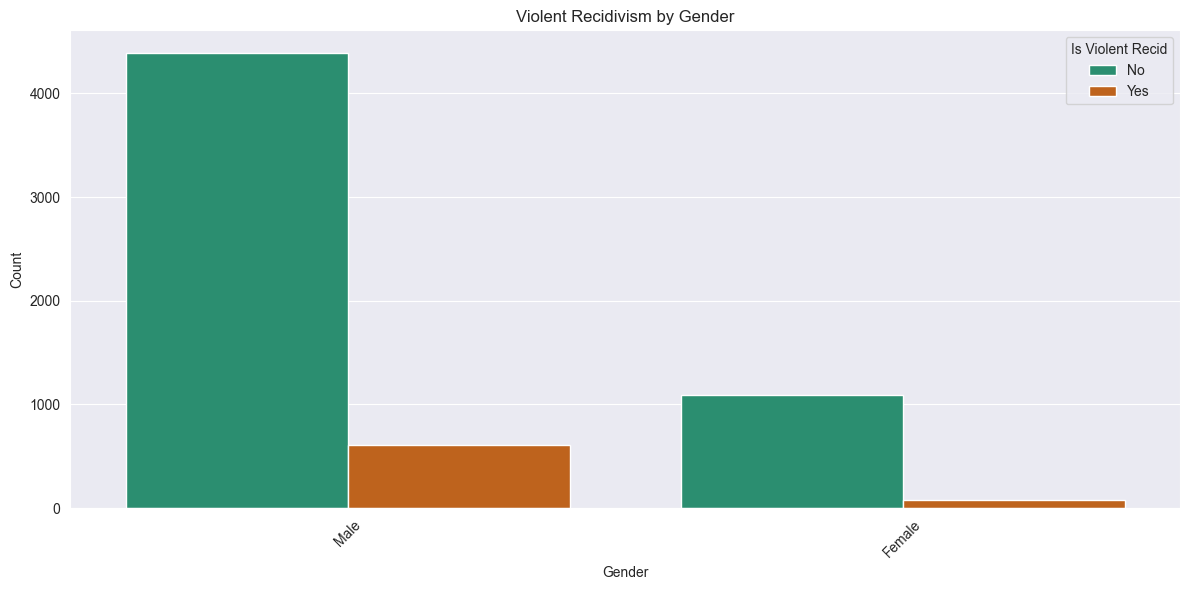

In [196]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, x='sex', hue='is_violent_recid', palette='Dark2', dodge=True)

plt.title("Violent Recidivism by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='Is Violent Recid', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

## 2.4 Violent Recidivism by Age Category


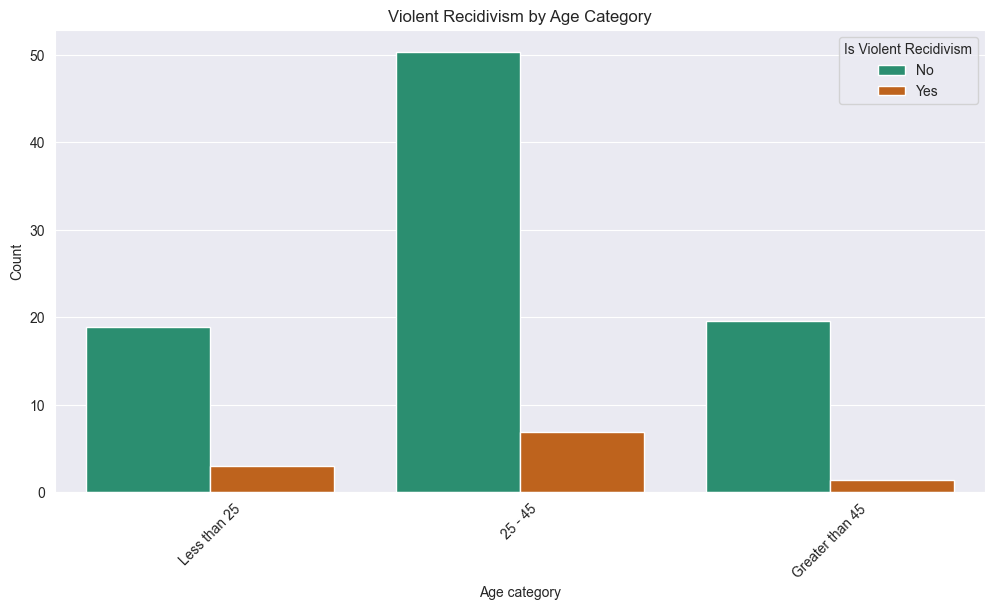

In [197]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, x='age_cat', hue='is_violent_recid' , palette='Dark2', stat='percent', dodge=True, order=['Less than 25', '25 - 45', 'Greater than 45'])
plt.title("Violent Recidivism by Age Category")
plt.xlabel("Age category")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Is Violent Recidivism', labels=['No', 'Yes'])
plt.show()

## 2.5 Decile Scores by Race

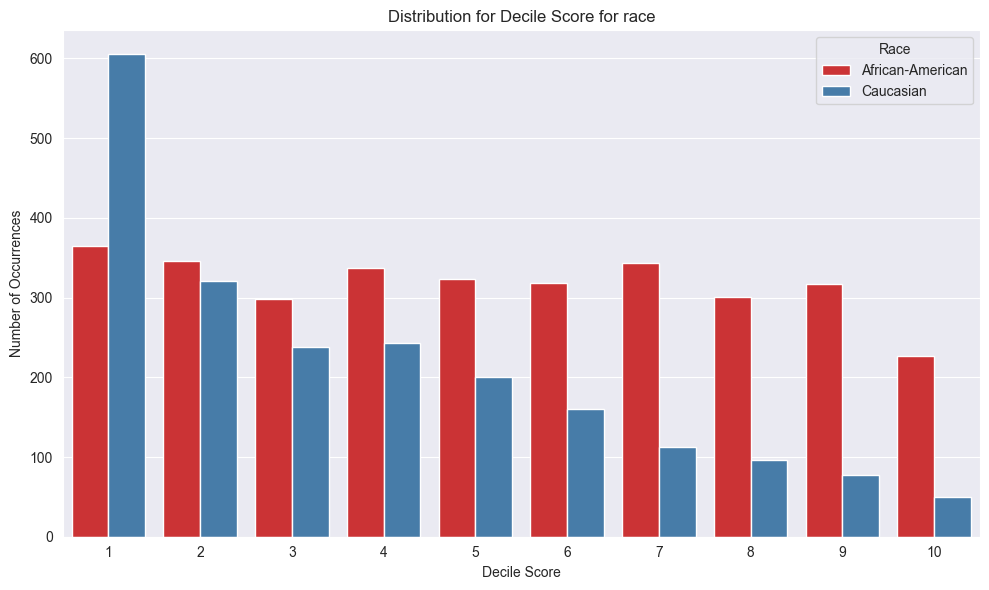

In [198]:
subset = df_cleaned[df_cleaned['race'].isin(['African-American', 'Caucasian'])].copy()
subset['decile_score'] = subset['decile_score'].astype(int).astype(str)

decile_order = [str(i) for i in range(1, 11)]

plt.figure(figsize=(10, 6))
sns.countplot(data=subset, x='decile_score', hue='race', palette='Set1', order=decile_order)

plt.title("Distribution for Decile Score for race")
plt.xlabel("Decile Score")
plt.ylabel("Number of Occurrences")
plt.legend(title="Race")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 2.6 Priors Count vs. Violent Recidivism

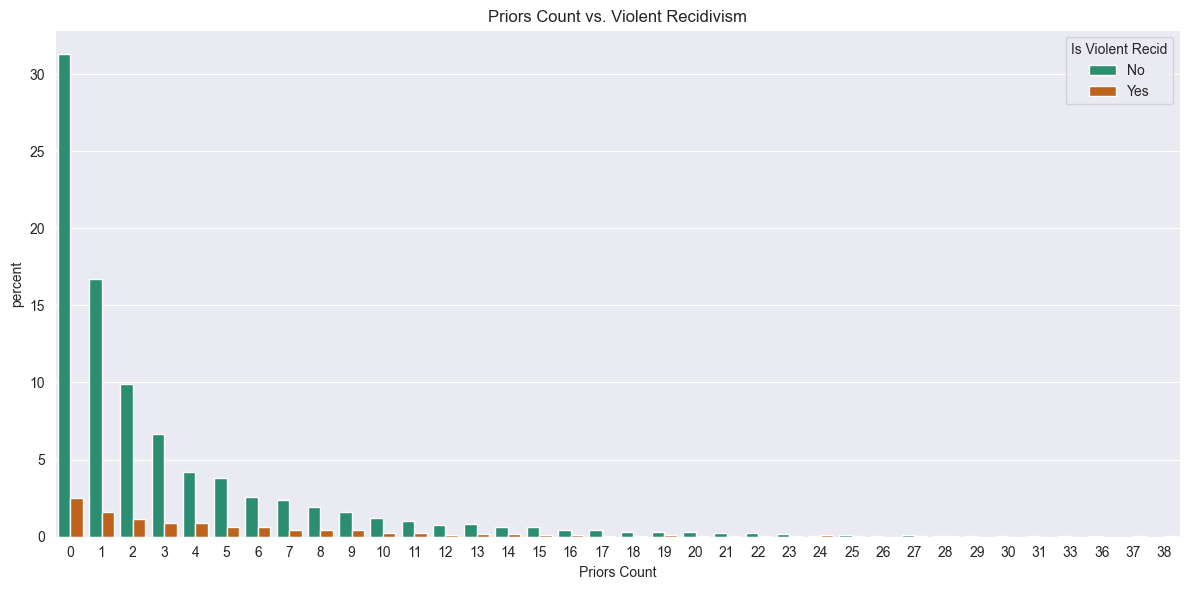

In [199]:
plt.figure(figsize=(12, 6))

sns.countplot(df_cleaned, x='priors_count', hue='is_violent_recid', palette='Dark2', stat='percent', dodge=True)
plt.xlabel("Priors Count")
plt.legend(title='Is Violent Recid', labels=['No', 'Yes'])
plt.title('Priors Count vs. Violent Recidivism')

plt.tight_layout()

## 2.7 Lenght of day

In [200]:
def categorize_length_of_stay(days):
    if days < 30:
        return 'less 1 month'
    elif 30 <= days <= 365:
        return '1 month - 1 year'
    else:
        return 'more than 1 year'

df_cleaned['c_length_of_stay'] = df_cleaned['length_of_stay'].apply(categorize_length_of_stay)

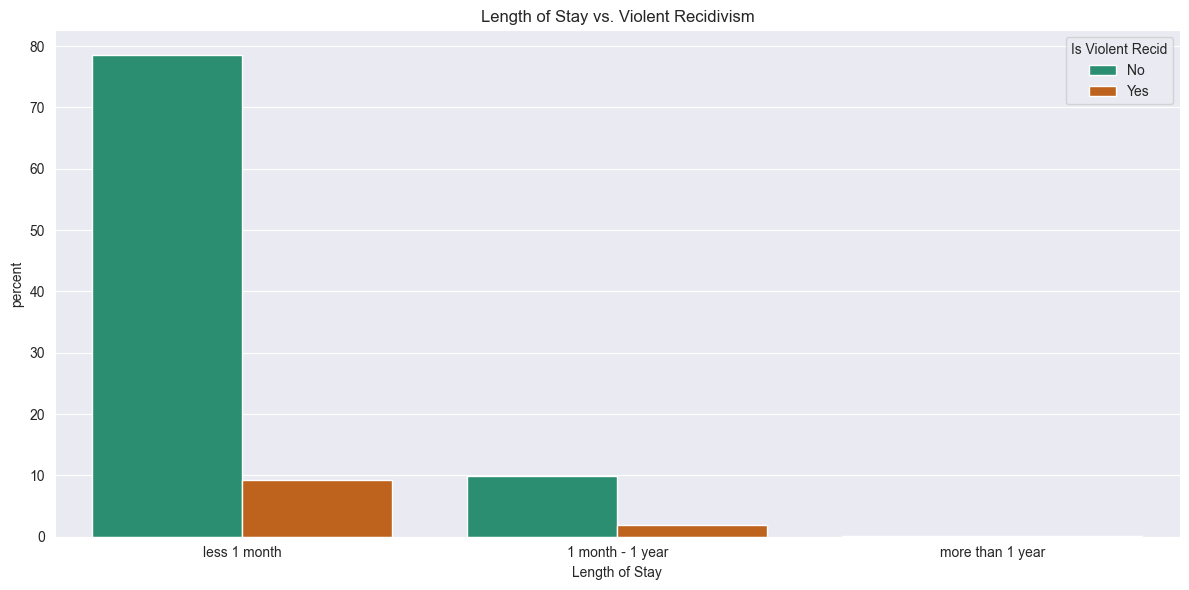

In [201]:
plt.figure(figsize=(12, 6))

sns.countplot(df_cleaned, x='c_length_of_stay', hue='is_violent_recid', palette='Dark2', stat='percent', dodge=True)
plt.xlabel("Length of Stay")
plt.legend(title='Is Violent Recid', labels=['No', 'Yes'])
plt.title('Length of Stay vs. Violent Recidivism')

plt.tight_layout()

In [202]:
df_cleaned = df_cleaned.drop(columns=['c_length_of_stay'], errors='ignore')

# 3. Develop Machine Learning Models and Evaluate their Performance

Functions

In [203]:
def train_xgboost_with_metrics_plot(X_train, y_train, scoring='f1'):
    param_grid = {
        'n_estimators': [100, 200, 500,1000],
        'learning_rate': [0.05,0.001,0.1],
        'max_depth': [3, 5,10],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'gamma': [0, 1]
    }

    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=5,
        n_jobs=-1,
        verbose=1,
        return_train_score=False
    )

    grid_search.fit(X_train, y_train)

    print("\nBest Hyperparameters:")
    print(grid_search.best_params_)

    return grid_search.best_params_, grid_search.best_estimator_, grid_search.cv_results_

## 3.1 Train Model

In [204]:
X = df_encoded.drop(columns=['two_year_recid'])
y = df_encoded['two_year_recid']

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [206]:
best_params, best_model, grid_results = train_xgboost_with_metrics_plot(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Best Hyperparameters:
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [207]:
best_params.pop('n_estimators', None)
n = 100

final_model = XGBClassifier(
    **best_params,
    n_estimators=1000,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

f1_scores = []
for i in range(1, n):
    final_model.set_params(n_estimators=i)
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_train)
    f1 = f1_score(y_train, y_pred)
    f1_scores.append(f1)
    print(f"n_estimators: {i}, F1 Score: {f1:.4f}")



n_estimators: 1, F1 Score: 0.0000
n_estimators: 2, F1 Score: 0.8953
n_estimators: 3, F1 Score: 0.9603
n_estimators: 4, F1 Score: 0.9391
n_estimators: 5, F1 Score: 0.9884
n_estimators: 6, F1 Score: 0.9889
n_estimators: 7, F1 Score: 0.9892
n_estimators: 8, F1 Score: 0.9892
n_estimators: 9, F1 Score: 0.9892
n_estimators: 10, F1 Score: 0.9894
n_estimators: 11, F1 Score: 0.9894
n_estimators: 12, F1 Score: 0.9894
n_estimators: 13, F1 Score: 0.9894
n_estimators: 14, F1 Score: 0.9894
n_estimators: 15, F1 Score: 0.9894
n_estimators: 16, F1 Score: 0.9894
n_estimators: 17, F1 Score: 0.9894
n_estimators: 18, F1 Score: 0.9894
n_estimators: 19, F1 Score: 0.9894
n_estimators: 20, F1 Score: 0.9894
n_estimators: 21, F1 Score: 0.9894
n_estimators: 22, F1 Score: 0.9894
n_estimators: 23, F1 Score: 0.9894
n_estimators: 24, F1 Score: 0.9894
n_estimators: 25, F1 Score: 0.9894
n_estimators: 26, F1 Score: 0.9894
n_estimators: 27, F1 Score: 0.9894
n_estimators: 28, F1 Score: 0.9894
n_estimators: 29, F1 Score: 0

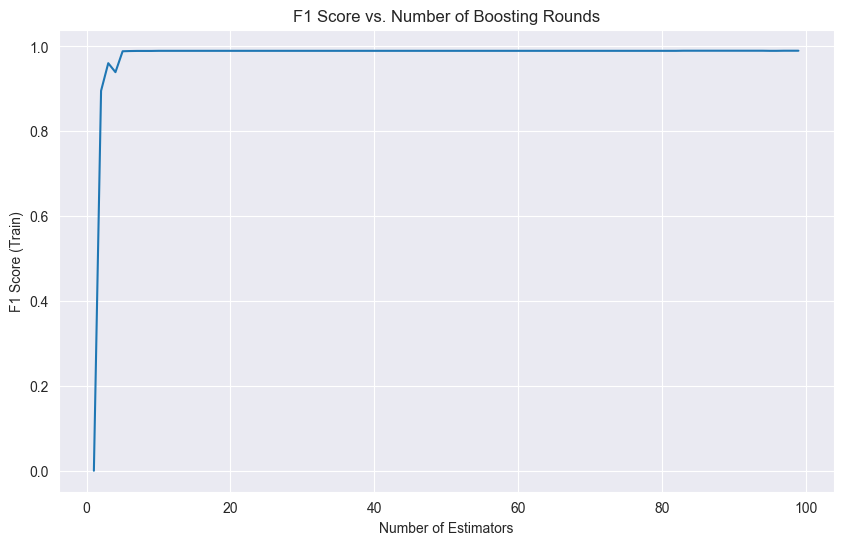

In [208]:
# 5. Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, n), f1_scores)
plt.xlabel("Number of Estimators")
plt.ylabel("F1 Score (Train)")
plt.title("F1 Score vs. Number of Boosting Rounds")
plt.grid(True)
plt.show()

In [209]:
final_model.set_params(n_estimators=15)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=15, n_jobs=None,
              num_parallel_tree=None, ...)

## 3.2 Evaluate Model

In [210]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

In [211]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1009
           1       0.99      1.00      0.99       843

    accuracy                           0.99      1852
   macro avg       0.99      0.99      0.99      1852
weighted avg       0.99      0.99      0.99      1852



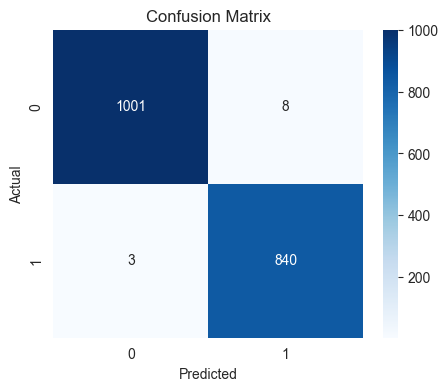

In [212]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 4. Explain the ML model(s) using an XAI technique

## 4.1 Feauture Importance

<Figure size 1600x1600 with 0 Axes>

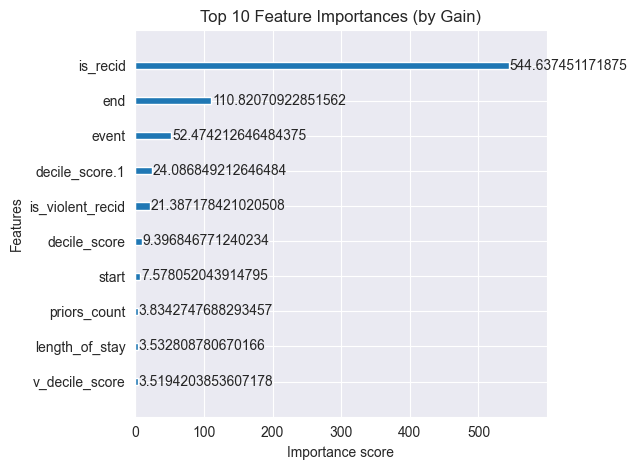

In [213]:
# Plot feature importance (based on gain, which is the most informative)
plt.figure(figsize=(16, 16))
plot_importance(final_model, importance_type='gain', max_num_features=10)
plt.title('Top 10 Feature Importances (by Gain)')
plt.tight_layout()
plt.show()

# 5. SHAP Analysis

In this section, we'll use SHAP (SHapley Additive exPlanations) to understand how our model makes predictions and which features are most important in the decision-making process.

## 5.1 Data Preparation and Model Training

First, we'll prepare our data and train an XGBoost model that we'll use for SHAP analysis.

In [214]:
# Select relevant features
features = ['age', 'priors_count.1', 'sex', 'race', 'v_decile_score']
X = df[features].copy()
y = df['two_year_recid']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['sex', 'race'], drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost model
model = XGBClassifier(eval_metric="logloss", random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## 5.2 Global Feature Importance

Let's analyze the global importance of features using SHAP values.

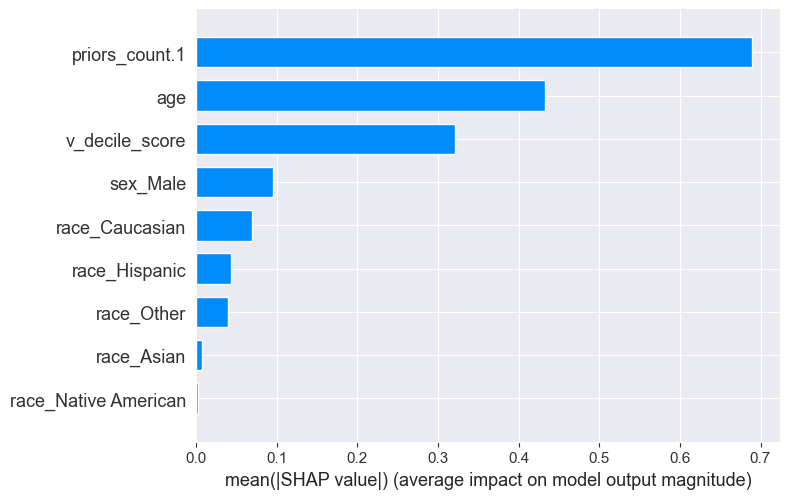

In [215]:
# Use TreeExplainer for tree-based models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


## 5.3 Feature Dependence Analysis

Let's examine how individual features affect the model's predictions.

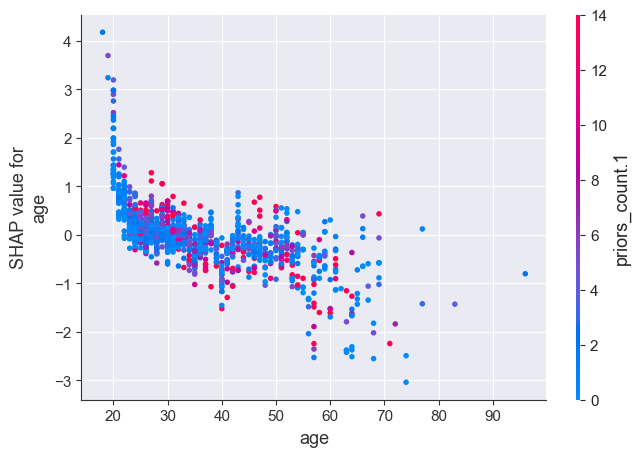

In [216]:
# SHAP dependence plot for "age"
shap.dependence_plot("age", shap_values, X_test, show=False)

## 5.4 Quantitative Feature Importance

Let's calculate and display the mean absolute SHAP values for each feature.


Feature Importance (Mean |SHAP|):
                Feature  Mean |SHAP value|
1        priors_count.1           0.689696
0                   age           0.432422
2        v_decile_score           0.321424
3              sex_Male           0.095928
5        race_Caucasian           0.068823
6         race_Hispanic           0.042997
8            race_Other           0.039524
4            race_Asian           0.007066
7  race_Native American           0.002537


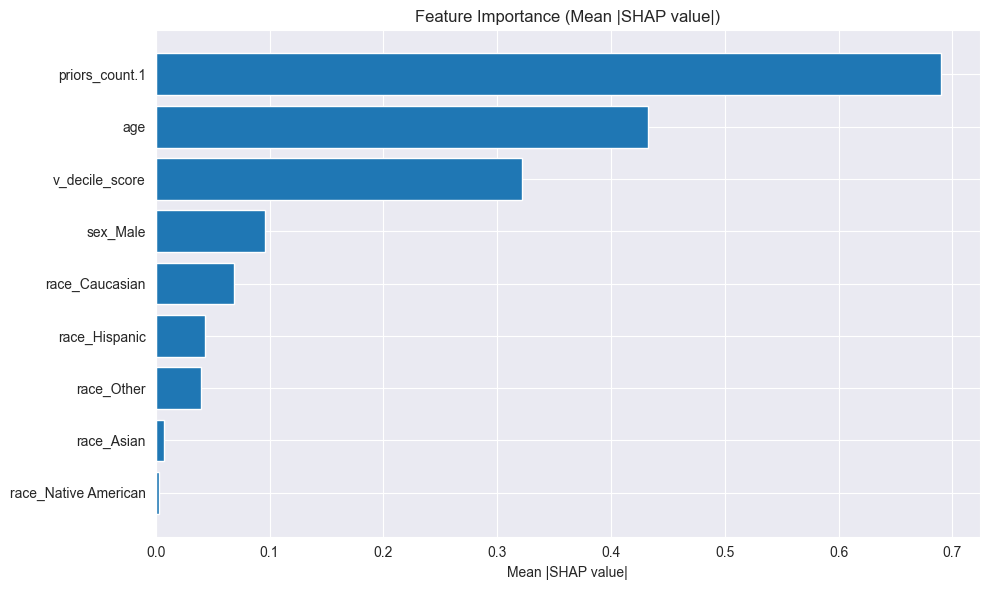

In [217]:
# Compute mean |SHAP| per feature
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP value|": np.abs(shap_values).mean(axis=0)
}).sort_values(by="Mean |SHAP value|", ascending=False)

# Display results
print("\nFeature Importance (Mean |SHAP|):")
print(importance_df)

# Optional bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Mean |SHAP value|"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Mean |SHAP value|)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()


## 5.5 SHAP Analysis Insights

Key takeaways from the SHAP analysis:

1. The most influential predictors of recidivism are:
   - Prior criminal history (`priors_count`)
   - Age
   - COMPAS risk score (`v_decile_score`)


2. SHAP reveals that:
   - Younger individuals are more likely to be predicted as reoffenders
   - Recidivism risk decreases with age

3. The model relies on both behavioral (priors) and demographic (age, race) factors, highlighting areas where bias may occur.


# 6. Enhancing the Fairness of the Machine Learning Model

In this section, we evaluate the fairness of our model with respect to a protected attribute (race), and apply a mitigation strategy to reduce bias.


## 6.1 Identifying the Protected Attribute and Calculating Bias Metrics

We define two fairness metrics:
- **Disparate Impact (DI)**: Measures the ratio of positive outcomes between protected and unprotected groups.
- **Equal Opportunity Difference (EO)**: Compares the true positive rates across groups.

We use `race_African-American` as the protected attribute.


In [221]:
from sklearn.metrics import confusion_matrix
import numpy as np

def calculate_disparate_impact(y_true, y_pred, protected_attribute):
    """
    Disparate Impact = P(Y=1 | A=0) / P(Y=1 | A=1)
    """
    prob_0 = np.mean(y_pred[protected_attribute == 0])
    prob_1 = np.mean(y_pred[protected_attribute == 1])
    di = prob_0 / prob_1 if prob_1 != 0 else float('inf')
    return di

def calculate_equal_opportunity(y_true, y_pred, protected_attribute):
    """
    Equal Opportunity = |TPR_A=0 - TPR_A=1|
    """
    tp_0 = np.sum((y_pred == 1) & (y_true == 1) & (protected_attribute == 0))
    tp_1 = np.sum((y_pred == 1) & (y_true == 1) & (protected_attribute == 1))

    total_0 = np.sum((y_true == 1) & (protected_attribute == 0))
    total_1 = np.sum((y_true == 1) & (protected_attribute == 1))

    prob_0 = tp_0 / total_0 if total_0 != 0 else 0
    prob_1 = tp_1 / total_1 if total_1 != 0 else 0

    eo_diff = abs(prob_0 - prob_1)
    return eo_diff

# Predictions from the original model
y_pred = model.predict(X_test)
protected_attribute = (df.loc[X_test.index, 'race'] == 'African-American').astype(int).values

# Bias metrics for original model
di_original = calculate_disparate_impact(y_test, y_pred, protected_attribute)
eo_original = calculate_equal_opportunity(y_test, y_pred, protected_attribute)

print("Original Model Bias Metrics:")
print(f"Disparate Impact: {di_original:.3f}")
print(f"Equal Opportunity Difference: {eo_original:.3f}")


Original Model Bias Metrics:
Disparate Impact: 0.544
Equal Opportunity Difference: 0.294


## 6.2 Applying Bias Mitigation (Reweighting)

To reduce bias, we apply a simple reweighting strategy using class weights during model training.


In [223]:
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights for class rebalancing
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Train fair model using sample weights
fair_model = XGBClassifier(random_state=42)
fair_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predictions and fairness metrics
y_pred_fair = fair_model.predict(X_test)
di_fair = calculate_disparate_impact(y_test, y_pred_fair, protected_attribute)
eo_fair = calculate_equal_opportunity(y_test, y_pred_fair, protected_attribute)

print("\nFair Model Bias Metrics:")
print(f"Disparate Impact: {di_fair:.3f}")
print(f"Equal Opportunity Difference: {eo_fair:.3f}")


Fair Model Bias Metrics:
Disparate Impact: 0.567
Equal Opportunity Difference: 0.271


## 6.3 Comparing Model Performance

We compare the performance of the original and fair models using standard classification metrics: Accuracy, Precision, Recall, and F1-score.


In [224]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

# Compute metrics
metrics_original = calculate_metrics(y_test, y_pred)
metrics_fair = calculate_metrics(y_test, y_pred_fair)

# Display results
print("\nPerformance Comparison:")

print("\nOriginal Model:")
for metric, value in metrics_original.items():
    print(f"{metric}: {value:.3f}")

print("\nFair Model:")
for metric, value in metrics_fair.items():
    print(f"{metric}: {value:.3f}")



Performance Comparison:

Original Model:
Accuracy: 0.672
Precision: 0.661
Recall: 0.557
F1: 0.604

Fair Model:
Accuracy: 0.669
Precision: 0.635
Recall: 0.623
F1: 0.629


# 7. Explaining the Fair Model Using SHAP

We now analyze how the fair model makes predictions by computing SHAP values.
This allows us to understand which features contribute most and whether fairness interventions changed the model's behavior.


## 7.1 Creating a SHAP Explainer for the Fair Model

We use SHAP's TreeExplainer to compute SHAP values for the fair model predictions.


In [225]:
# Create SHAP explainer for the fair model
fair_explainer = shap.TreeExplainer(fair_model)
fair_shap_values = fair_explainer.shap_values(X_test)


## 7.2 Global Feature Importance for the Fair Model

We generate a bar plot showing the average SHAP values across features.


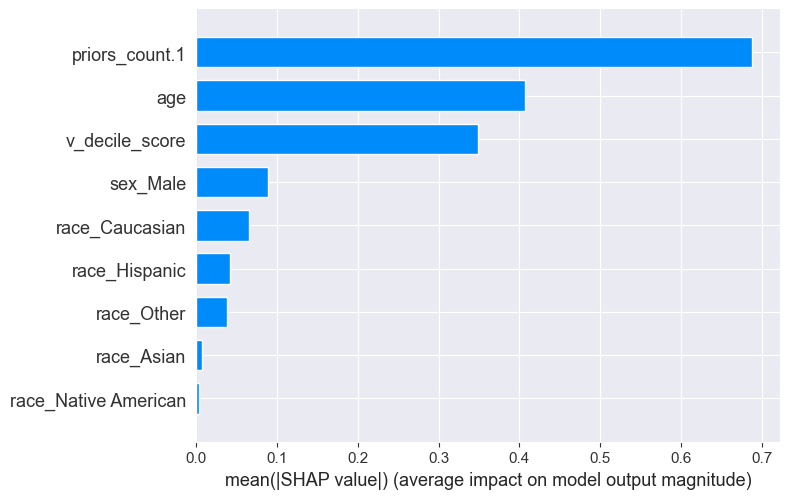

In [226]:
# SHAP summary bar plot for fair model
shap.summary_plot(fair_shap_values, X_test, plot_type="bar")


## 7.3 SHAP Dependence Plot for "age"

We analyze how the value of the `age` feature affects predictions in the fair model.


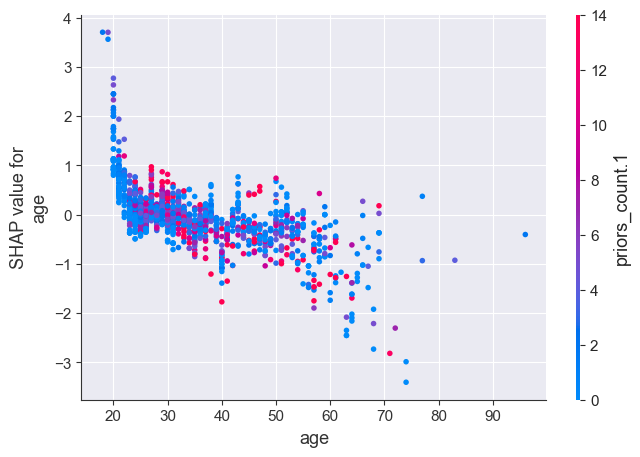

In [227]:
# SHAP dependence plot for "age" in fair model
shap.dependence_plot("age", fair_shap_values, X_test)


## 7.4 Calculating Feature Importance (Mean |SHAP|) for the Fair Model

We compute the mean absolute SHAP value for each feature.


In [228]:
# Calculate and display SHAP feature importance for fair model
fair_feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': np.abs(fair_shap_values).mean(axis=0)
}).sort_values('Importance', ascending=False)

print("\nFeature Importance for Fair Model (Mean |SHAP|):")
print(fair_feature_importance)



Feature Importance for Fair Model (Mean |SHAP|):
                Feature  Importance
1        priors_count.1    0.687821
0                   age    0.407112
2        v_decile_score    0.349255
3              sex_Male    0.088360
5        race_Caucasian    0.064972
6         race_Hispanic    0.041541
8            race_Other    0.038306
4            race_Asian    0.007658
7  race_Native American    0.003063


## 7.5 Comparing Feature Importance Between Original and Fair Models

We compare the average SHAP values across features to identify which variables were affected by the fairness intervention.


In [229]:
# Compare feature importance values between original and fair models
comparison_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Original_Importance': np.abs(shap_values).mean(axis=0),
    'Fair_Importance': np.abs(fair_shap_values).mean(axis=0)
})
comparison_df['Difference'] = comparison_df['Fair_Importance'] - comparison_df['Original_Importance']
comparison_df = comparison_df.sort_values('Difference', ascending=False)

print("\nFeature Importance Comparison (Fair - Original):")
print(comparison_df)



Feature Importance Comparison (Fair - Original):
                Feature  Original_Importance  Fair_Importance  Difference
2        v_decile_score             0.321424         0.349255    0.027831
4            race_Asian             0.007066         0.007658    0.000592
7  race_Native American             0.002537         0.003063    0.000525
8            race_Other             0.039524         0.038306   -0.001218
6         race_Hispanic             0.042997         0.041541   -0.001456
1        priors_count.1             0.689696         0.687821   -0.001875
5        race_Caucasian             0.068823         0.064972   -0.003851
3              sex_Male             0.095928         0.088360   -0.007569
0                   age             0.432422         0.407112   -0.025310


## 7.6 Visualizing the Change in Feature Importance

We create a bar chart comparing the feature importances before and after applying fairness-based reweighting.


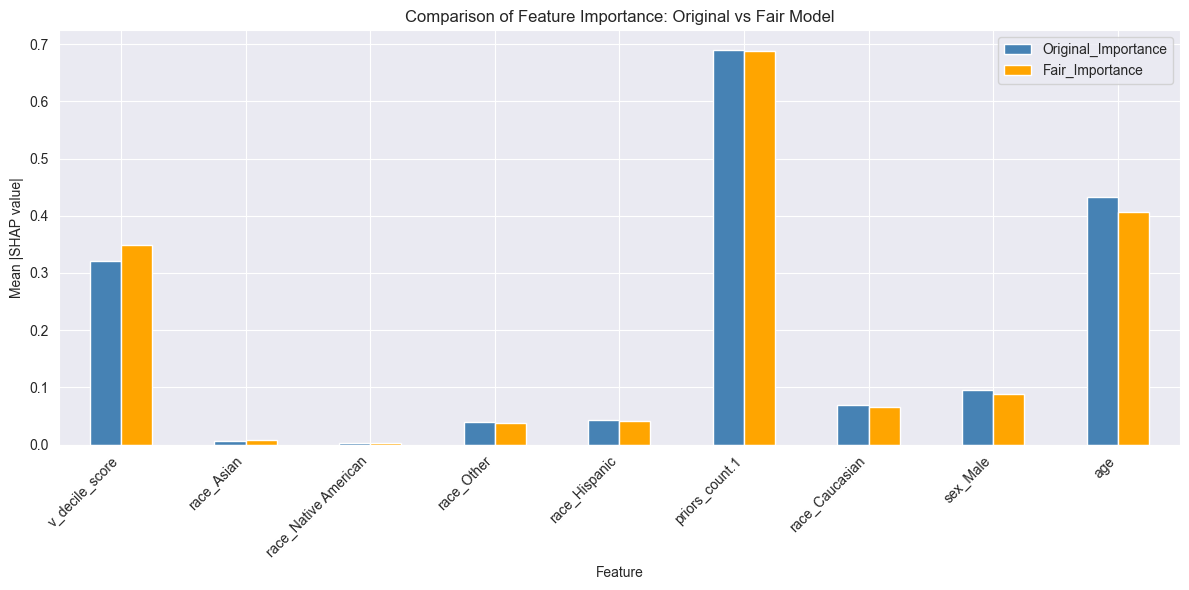

In [230]:
# Visualize comparison of feature importance
comparison_df.set_index("Feature")[['Original_Importance', 'Fair_Importance']].plot(
    kind='bar', figsize=(12, 6), color=["steelblue", "orange"]
)
plt.title('Comparison of Feature Importance: Original vs Fair Model')
plt.ylabel("Mean |SHAP value|")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 8. Comparing the Performance and Fairness of ML Models

In this section, we compare the original and fair models in terms of both predictive performance and fairness.
We evaluate overall metrics, fairness metrics, and also analyze performance for each group defined by the protected attribute.


## 8.1 Overall Performance Metrics

We calculate classification metrics such as Accuracy, Precision, Recall, F1 Score, ROC AUC, and Average Precision for both models.


In [231]:
from sklearn.metrics import roc_auc_score, average_precision_score

def calculate_detailed_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_prob),
        'Average Precision': average_precision_score(y_true, y_prob)
    }

# Get probability predictions
y_prob_original = model.predict_proba(X_test)[:, 1]
y_prob_fair = fair_model.predict_proba(X_test)[:, 1]

# Calculate metrics
metrics_original = calculate_detailed_metrics(y_test, y_pred, y_prob_original)
metrics_fair = calculate_detailed_metrics(y_test, y_pred_fair, y_prob_fair)

# Create comparison DataFrame
comparison_metrics = pd.DataFrame({
    'Metric': list(metrics_original.keys()),
    'Original Model': list(metrics_original.values()),
    'Fair Model': list(metrics_fair.values())
})

print("\nDetailed Performance Comparison:")
print(comparison_metrics)



Detailed Performance Comparison:
              Metric  Original Model  Fair Model
0           Accuracy        0.671518    0.668746
1          Precision        0.660584    0.634796
2             Recall        0.556923    0.623077
3                 F1        0.604341    0.628882
4            ROC AUC        0.707846    0.709095
5  Average Precision        0.663813    0.667402


## 8.2 Fairness Metrics

We calculate and compare two fairness metrics: Disparate Impact and Equal Opportunity Difference.


In [232]:
def calculate_fairness_metrics(y_true, y_pred, protected_attribute):
    return {
        'Disparate Impact': calculate_disparate_impact(y_true, y_pred, protected_attribute),
        'Equal Opportunity Difference': calculate_equal_opportunity(y_true, y_pred, protected_attribute)
    }

fairness_original = calculate_fairness_metrics(y_test, y_pred, protected_attribute)
fairness_fair = calculate_fairness_metrics(y_test, y_pred_fair, protected_attribute)

# Create fairness comparison DataFrame
comparison_fairness = pd.DataFrame({
    'Fairness Metric': list(fairness_original.keys()),
    'Original Model': list(fairness_original.values()),
    'Fair Model': list(fairness_fair.values())
})

print("\nFairness Metrics Comparison:")
print(comparison_fairness)



Fairness Metrics Comparison:
                Fairness Metric  Original Model  Fair Model
0              Disparate Impact        0.543643    0.567141
1  Equal Opportunity Difference        0.294137    0.270577


## 8.3 Visualizing Performance Metrics

We use a bar chart to compare all performance metrics between the two models.


<Figure size 1200x600 with 0 Axes>

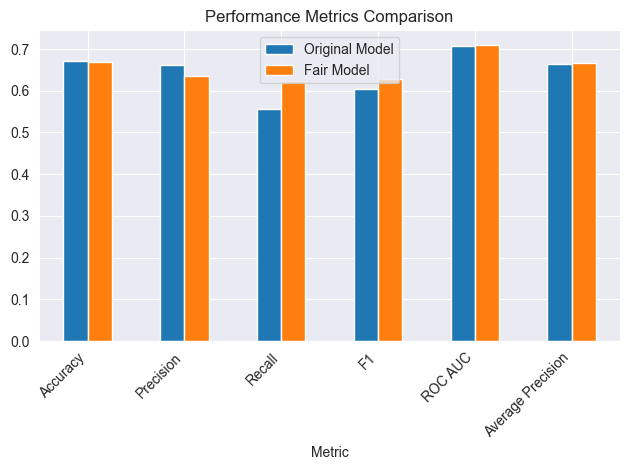

In [233]:
plt.figure(figsize=(12, 6))
comparison_metrics.plot(x='Metric', y=['Original Model', 'Fair Model'], kind='bar')
plt.title('Performance Metrics Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 8.4 Visualizing Fairness Metrics

We use a bar chart to compare fairness metrics between the original and fair models.


<Figure size 1000x600 with 0 Axes>

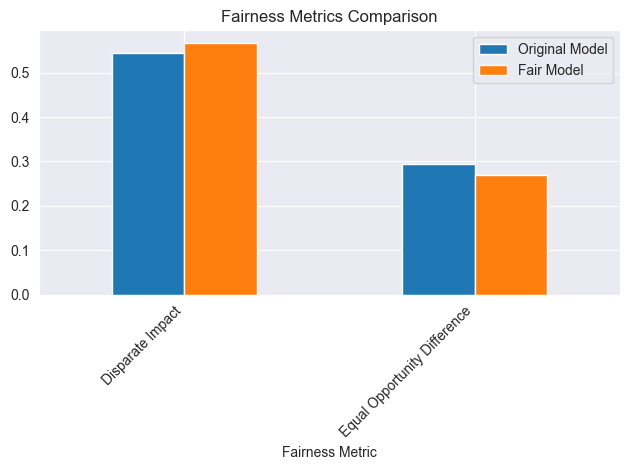

In [234]:
plt.figure(figsize=(10, 6))
comparison_fairness.plot(x='Fairness Metric', y=['Original Model', 'Fair Model'], kind='bar')
plt.title('Fairness Metrics Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 8.5 Group-wise Performance by Protected Attribute

We analyze Accuracy and F1 Score separately for the protected group (African-American) and the unprotected group.


In [235]:
def calculate_group_metrics(y_true, y_pred, protected_attribute):
    metrics = {}
    for group in [0, 1]:
        mask = protected_attribute == group
        group_name = 'Non-African-American' if group == 0 else 'African-American'
        metrics[group_name] = {
            'Accuracy': accuracy_score(y_true[mask], y_pred[mask]),
            'Precision': precision_score(y_true[mask], y_pred[mask]),
            'Recall': recall_score(y_true[mask], y_pred[mask]),
            'F1': f1_score(y_true[mask], y_pred[mask])
        }
    return metrics

# Calculate group-wise metrics
group_metrics_original = calculate_group_metrics(y_test, y_pred, protected_attribute)
group_metrics_fair = calculate_group_metrics(y_test, y_pred_fair, protected_attribute)

# Assemble comparison DataFrame
group_comparison = pd.DataFrame({
    'Group': ['Non-African-American', 'African-American'] * 2,
    'Model': ['Original'] * 2 + ['Fair'] * 2,
    'Accuracy': [group_metrics_original['Non-African-American']['Accuracy'],
                 group_metrics_original['African-American']['Accuracy'],
                 group_metrics_fair['Non-African-American']['Accuracy'],
                 group_metrics_fair['African-American']['Accuracy']],
    'F1': [group_metrics_original['Non-African-American']['F1'],
           group_metrics_original['African-American']['F1'],
           group_metrics_fair['Non-African-American']['F1'],
           group_metrics_fair['African-American']['F1']]
})

print("\nPerformance by Protected Attribute:")
print(group_comparison)



Performance by Protected Attribute:
                  Group     Model  Accuracy        F1
0  Non-African-American  Original  0.646393  0.461207
1      African-American  Original  0.695652  0.694823
2  Non-African-American      Fair  0.656294  0.514970
3      African-American      Fair  0.680707  0.701398


## 8.6 Visualizing Group-level F1 Scores

We plot F1 Scores by group and by model to check if performance is balanced across groups.


<Figure size 1200x600 with 0 Axes>

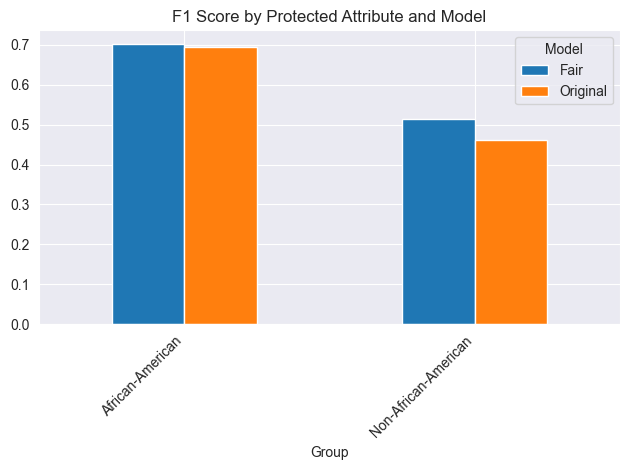

In [236]:
plt.figure(figsize=(12, 6))
group_comparison.pivot(index='Group', columns='Model', values='F1').plot(kind='bar')
plt.title('F1 Score by Protected Attribute and Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 9. Analyze Change in Model Behavior (Qualitative Analysis)

In this section, we explore qualitative changes in behavior between the original and fair models.
We compare predictions, SHAP values, and prediction distributions across groups and individual samples.


## 9.1 Comparing SHAP Values for Individual Predictions

We randomly select individual test cases and compare their predictions and SHAP explanations between the original and fair models.


In [238]:
def analyze_individual_predictions(model, fair_model, X_test, n_samples=5):
    """
    Compare predictions and SHAP explanations for selected test samples
    """
    sample_indices = np.random.choice(len(X_test), n_samples, replace=False)
    sample_X = X_test.iloc[sample_indices]

    pred_original = model.predict(sample_X)
    pred_fair = fair_model.predict(sample_X)
    prob_original = model.predict_proba(sample_X)[:, 1]
    prob_fair = fair_model.predict_proba(sample_X)[:, 1]

    explainer_original = shap.TreeExplainer(model)
    explainer_fair = shap.TreeExplainer(fair_model)
    shap_original = explainer_original.shap_values(sample_X)
    shap_fair = explainer_fair.shap_values(sample_X)

    comparison = pd.DataFrame({
        'Case': range(n_samples),
        'Original_Prediction': pred_original,
        'Fair_Prediction': pred_fair,
        'Original_Probability': prob_original,
        'Fair_Probability': prob_fair,
        'Prediction_Changed': pred_original != pred_fair
    })

    return comparison, shap_original, shap_fair, sample_X

# Run analysis
comparison_df, shap_original, shap_fair, sample_X = analyze_individual_predictions(model, fair_model, X_test)

print("\nIndividual Case Analysis:")
print(comparison_df)



Individual Case Analysis:
   Case  Original_Prediction  Fair_Prediction  Original_Probability  \
0     0                    1                1              0.756623   
1     1                    1                1              0.595000   
2     2                    1                1              0.908922   
3     3                    1                1              0.904138   
4     4                    0                0              0.240930   

   Fair_Probability  Prediction_Changed  
0          0.645589               False  
1          0.647981               False  
2          0.903639               False  
3          0.872783               False  
4          0.188250               False  


## 9.2 Visualizing SHAP Value Changes for Changed Predictions

We visualize SHAP explanations only for those cases where the prediction changed between the models.


In [239]:
changed_cases = comparison_df[comparison_df['Prediction_Changed']]

if not changed_cases.empty:
    for idx in changed_cases.index:
        case_idx = comparison_df.loc[idx, 'Case']

        plt.figure(figsize=(10, 4))

        # SHAP from original model
        plt.subplot(1, 2, 1)
        shap.summary_plot(shap_original[case_idx:case_idx+1], sample_X.iloc[case_idx:case_idx+1],
                         plot_type="bar", show=False)
        plt.title(f"Original Model - Case {case_idx}")

        # SHAP from fair model
        plt.subplot(1, 2, 2)
        shap.summary_plot(shap_fair[case_idx:case_idx+1], sample_X.iloc[case_idx:case_idx+1],
                         plot_type="bar", show=False)
        plt.title(f"Fair Model - Case {case_idx}")

        plt.tight_layout()
        plt.show()


## 9.3 Feature Importance by Protected Group

We compute the average SHAP values separately for each protected group to detect any change in feature attribution.


In [240]:
def analyze_feature_importance_by_group(shap_values, X_test, protected_attribute):
    group_0_importance = np.abs(shap_values[protected_attribute == 0]).mean(axis=0)
    group_1_importance = np.abs(shap_values[protected_attribute == 1]).mean(axis=0)

    return pd.DataFrame({
        'Feature': X_test.columns,
        'Non-African-American': group_0_importance,
        'African-American': group_1_importance
    })

original_group_importance = analyze_feature_importance_by_group(shap_values, X_test, protected_attribute)
fair_group_importance = analyze_feature_importance_by_group(fair_shap_values, X_test, protected_attribute)

print("\nFeature Importance by Protected Group - Original Model:")
print(original_group_importance)

print("\nFeature Importance by Protected Group - Fair Model:")
print(fair_group_importance)



Feature Importance by Protected Group - Original Model:
                Feature  Non-African-American  African-American
0                   age              0.416634          0.447588
1        priors_count.1              0.644552          0.733061
2        v_decile_score              0.335946          0.307474
3              sex_Male              0.094502          0.097298
4            race_Asian              0.011026          0.003262
5        race_Caucasian              0.087452          0.050928
6         race_Hispanic              0.061055          0.025651
7  race_Native American              0.004358          0.000789
8            race_Other              0.063464          0.016528

Feature Importance by Protected Group - Fair Model:
                Feature  Non-African-American  African-American
0                   age              0.404213          0.409896
1        priors_count.1              0.644610          0.729330
2        v_decile_score              0.365633          0.3

## 9.4 Visualizing Group-based Feature Importance

We compare the group-level SHAP feature importance before and after applying the fairness technique.


<Figure size 1200x600 with 0 Axes>

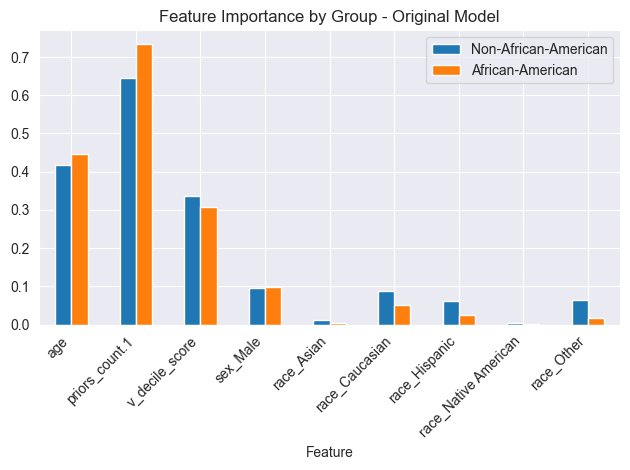

<Figure size 1200x600 with 0 Axes>

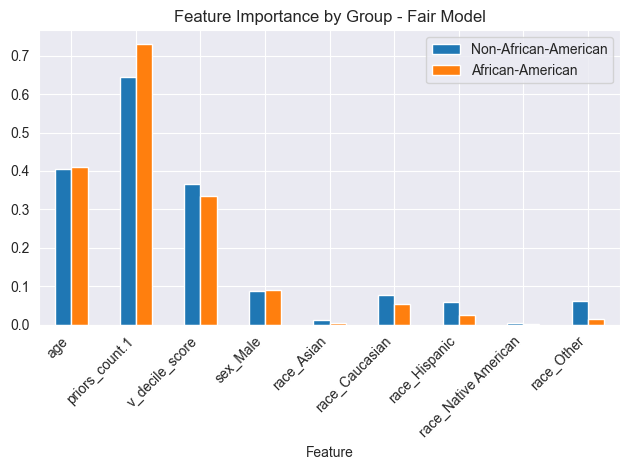

In [241]:
# Original model
plt.figure(figsize=(12, 6))
original_group_importance.plot(x='Feature', y=['Non-African-American', 'African-American'],
                               kind='bar', title='Feature Importance by Group - Original Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Fair model
plt.figure(figsize=(12, 6))
fair_group_importance.plot(x='Feature', y=['Non-African-American', 'African-American'],
                           kind='bar', title='Feature Importance by Group - Fair Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 9.5 Prediction Rate Changes by Group

We compare how often each group receives positive predictions under the original and fair models.


In [242]:
def analyze_prediction_distribution(y_pred_original, y_pred_fair, protected_attribute):
    rates_original = {
        'Non-African-American': np.mean(y_pred_original[protected_attribute == 0]),
        'African-American': np.mean(y_pred_original[protected_attribute == 1])
    }

    rates_fair = {
        'Non-African-American': np.mean(y_pred_fair[protected_attribute == 0]),
        'African-American': np.mean(y_pred_fair[protected_attribute == 1])
    }

    return pd.DataFrame({
        'Group': ['Non-African-American', 'African-American'] * 2,
        'Model': ['Original'] * 2 + ['Fair'] * 2,
        'Prediction_Rate': list(rates_original.values()) + list(rates_fair.values())
    })

prediction_distribution = analyze_prediction_distribution(y_pred, y_pred_fair, protected_attribute)

print("\nPrediction Distribution Analysis:")
print(prediction_distribution)



Prediction Distribution Analysis:
                  Group     Model  Prediction_Rate
0  Non-African-American  Original         0.265912
1      African-American  Original         0.489130
2  Non-African-American      Fair         0.318246
3      African-American      Fair         0.561141


## 9.6 Visualizing Prediction Rate Differences

We visualize how the average prediction rate differs across protected groups and models.


<Figure size 1000x600 with 0 Axes>

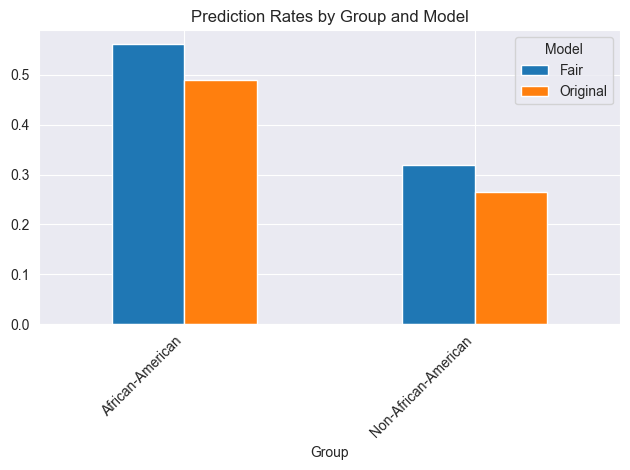

In [243]:
plt.figure(figsize=(10, 6))
prediction_distribution.pivot(index='Group', columns='Model', values='Prediction_Rate').plot(kind='bar')
plt.title('Prediction Rates by Group and Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 10. Quantifying Change in Model Behavior via SHAP Explanations

In this final section, we quantify how much the model’s internal reasoning (as measured by SHAP) changed due to the fairness intervention.
We use cosine similarity, absolute differences, and visualizations to support the analysis.


In [244]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_explanation_similarity(shap_values_1, shap_values_2):

    shap_1_2d = shap_values_1.reshape(shap_values_1.shape[0], -1)
    shap_2_2d = shap_values_2.reshape(shap_values_2.shape[0], -1)
    similarity = cosine_similarity(shap_1_2d, shap_2_2d)
    return np.diag(similarity)

explanation_similarity = calculate_explanation_similarity(shap_values, fair_shap_values)


## 10.2 Mean Absolute SHAP Differences

We calculate the average absolute difference in SHAP values per feature.
This shows which features changed most in importance.


In [245]:
shap_difference = np.abs(shap_values - fair_shap_values)
mean_difference = np.mean(shap_difference, axis=0)

difference_analysis = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Absolute_Difference': mean_difference,
    'Mean_Original_SHAP': np.abs(shap_values).mean(axis=0),
    'Mean_Fair_SHAP': np.abs(fair_shap_values).mean(axis=0)
}).sort_values('Mean_Absolute_Difference', ascending=False)

print("\nAnalysis of Changes in SHAP Values:")
print(difference_analysis)



Analysis of Changes in SHAP Values:
                Feature  Mean_Absolute_Difference  Mean_Original_SHAP  \
0                   age                  0.122407            0.432422   
2        v_decile_score                  0.096017            0.321424   
1        priors_count.1                  0.090181            0.689696   
5        race_Caucasian                  0.035667            0.068823   
3              sex_Male                  0.025616            0.095928   
6         race_Hispanic                  0.016044            0.042997   
8            race_Other                  0.010407            0.039524   
4            race_Asian                  0.001224            0.007066   
7  race_Native American                  0.000538            0.002537   

   Mean_Fair_SHAP  
0        0.407112  
2        0.349255  
1        0.687821  
5        0.064972  
3        0.088360  
6        0.041541  
8        0.038306  
4        0.007658  
7        0.003063  


## 10.3 Visualizing Feature Importance Changes

We plot the mean SHAP values from both models to visualize how each feature’s importance changed.


<Figure size 1200x600 with 0 Axes>

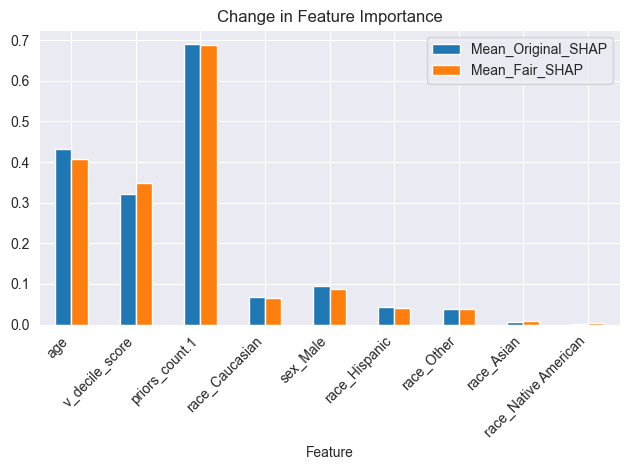

In [246]:
plt.figure(figsize=(12, 6))
difference_analysis.plot(x='Feature', y=['Mean_Original_SHAP', 'Mean_Fair_SHAP'], kind='bar')
plt.title('Change in Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 10.4 Feature Attribution Changes by Protected Group

We compute and compare SHAP changes between groups to understand if fairness altered explanations differently across demographic groups.


In [247]:
def analyze_changes_by_group(shap_values_1, shap_values_2, protected_attribute):
    diff_group_0 = np.mean(np.abs(shap_values_1[protected_attribute == 0] -
                                  shap_values_2[protected_attribute == 0]), axis=0)
    diff_group_1 = np.mean(np.abs(shap_values_1[protected_attribute == 1] -
                                  shap_values_2[protected_attribute == 1]), axis=0)

    return pd.DataFrame({
        'Feature': X_test.columns,
        'Non-African-American': diff_group_0,
        'African-American': diff_group_1
    })

group_changes = analyze_changes_by_group(shap_values, fair_shap_values, protected_attribute)

print("\nChanges in SHAP Values by Protected Group:")
print(group_changes)



Changes in SHAP Values by Protected Group:
                Feature  Non-African-American  African-American
0                   age              0.117627          0.126998
1        priors_count.1              0.083324          0.096767
2        v_decile_score              0.092957          0.098957
3              sex_Male              0.028766          0.022590
4            race_Asian              0.001825          0.000646
5        race_Caucasian              0.043302          0.028333
6         race_Hispanic              0.023354          0.009023
7  race_Native American              0.000927          0.000165
8            race_Other              0.015092          0.005906


## 10.5 Visualizing Group-level Explanation Changes

We visualize the SHAP value changes for each feature across protected groups.


<Figure size 1200x600 with 0 Axes>

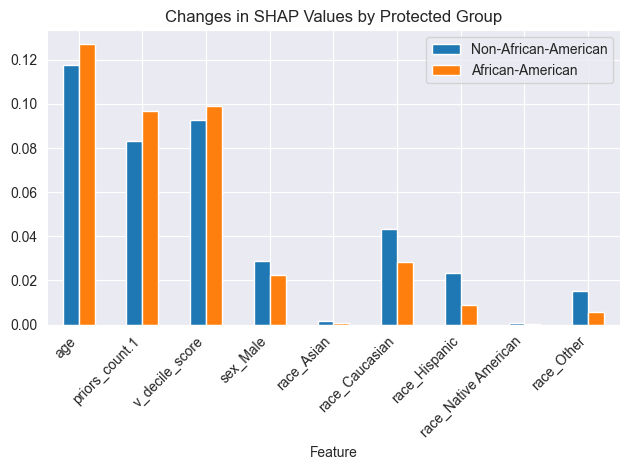

In [248]:
plt.figure(figsize=(12, 6))
group_changes.plot(x='Feature', y=['Non-African-American', 'African-American'], kind='bar')
plt.title('Changes in SHAP Values by Protected Group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 10.6 Summary Metrics for Explanation Changes

We summarize the overall change with aggregated metrics like mean cosine similarity and SHAP difference.


In [249]:
overall_metrics = {
    'Mean_Similarity': np.mean(explanation_similarity),
    'Std_Similarity': np.std(explanation_similarity),
    'Mean_Absolute_Difference': np.mean(mean_difference),
    'Max_Absolute_Difference': np.max(mean_difference)
}

print("\nOverall Change Metrics:")
for metric, value in overall_metrics.items():
    print(f"{metric}: {value:.4f}")



Overall Change Metrics:
Mean_Similarity: 0.9654
Std_Similarity: 0.0743
Mean_Absolute_Difference: 0.0442
Max_Absolute_Difference: 0.1224


## 10.7 Visualizing Explanation Similarity Distribution

We use a histogram to display how much SHAP explanations align between the two models on average.


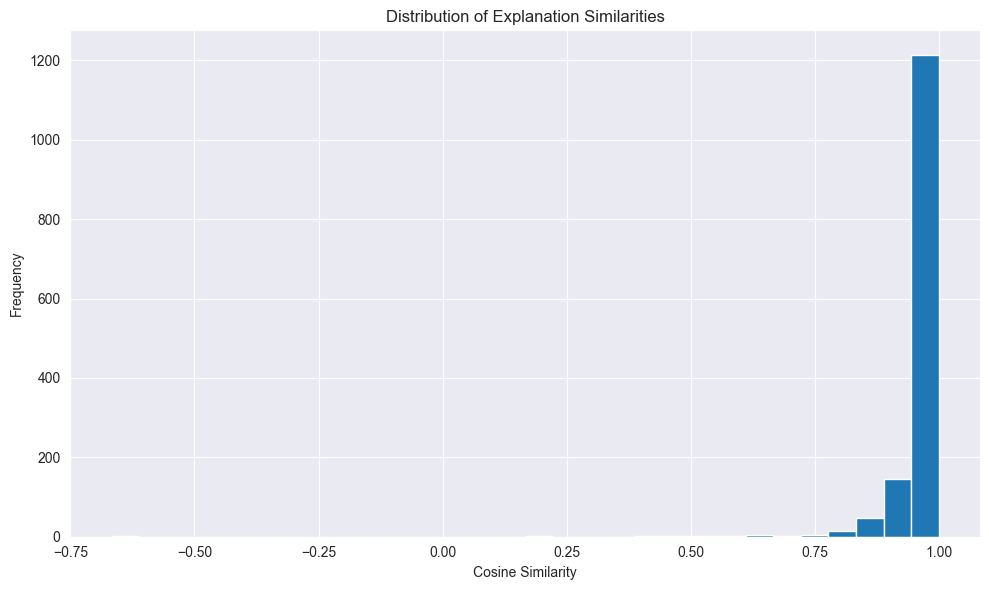

In [250]:
plt.figure(figsize=(10, 6))
plt.hist(explanation_similarity, bins=30)
plt.title('Distribution of Explanation Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
